In [1]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
from itertools import product
from datetime import datetime
from scipy.stats import gmean
from typing import Optional, List, Tuple
from IPython.display import display, HTML
from matplotlib.animation import FuncAnimation, PillowWriter
print('imported')

imported


In [2]:
# add the parent dir to the path to import from src/

parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# impot the algorithm components directly
from src.algorithm import (
    TensorNetwork,
    evaluate_config,
    update_edge,
    estimate_contraction,
    run_multiple_chains,
    contract_tensor_network
)


EPS = 1e-12

def gmean_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    return float(np.exp(np.mean(np.log(x))))

def gvar_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    return float(np.var(np.log(x), ddof=1))

def gstd_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    return float(np.std(np.log(x), ddof=1)) # dont exp, log 10

print('functions loaded')

functions loaded


In [3]:
# A = len(beta) = number of annealing steps
# B = n_chains  = number of parallel random walks
# C = iters     = number of Glauber updates per chain per annealing step

def create_test_tensor_network(network_type="2x2_ring", dim=3, seed=42,
                               eps=1e-6, alpha=0.6, spike_factor=10.0, jitter=0.1):
    """
    network_type options (topology + optional weight model):
      - "2x2_ring", "3x3_grid"                      (old behavior: N(1,0.1))
      - "2x2_ring_uniform1",   "3x3_grid_uniform1"  (uniform around 1, nonnegative)
      - "2x2_ring_diagexp",    "3x3_grid_diagexp"   (exponentially-decaying diagonal)
      - "2x2_ring_spikes",     "3x3_grid_spikes"    (uniform + diagonal spikes)

    dim: index range size for each leg
    alpha: decay rate for diagexp
    spike_factor: multiplicative spike on diagonal entries for spikes
    jitter: half-width of uniform around 1, i.e., U[1-jitter, 1+jitter]
    """
    np.random.seed(seed)

    if "_" in network_type:
        topo, model = network_type.rsplit("_", 1)
    else:
        topo, model = network_type, "gauss"   # old default

    def sample_tensor(shape, rng=np.random):
        k = len(shape)

        if model == "gauss":
            # previous default: N(1, 0.1)
            T = rng.normal(loc=1.0, scale=0.1, size=shape) + eps
            return T

        if model == "uniform1":
            # nonnegative, mildly varying around 1
            T = rng.uniform(1.0 - jitter, 1.0 + jitter, size=shape)
            T = np.maximum(T, eps)
            return T

        if model == "diagexp":
            # all mass on the "full diagonal" with exponential decay
            # build indices grid then mask where all indices are equal
            idx = np.indices(shape)
            mask = np.all(idx == idx[0], axis=0)
            T = np.full(shape, eps, dtype=float)
            # diagonal value ~ exp(-alpha * i) where i is that common index
            # take the first axis as representative
            diag_vals = np.exp(-alpha * np.arange(shape[0]))
            T[mask] = diag_vals[idx[0][mask]]
            return T

        if model == "spikes":
            # base uniform around 1
            T = rng.uniform(1.0 - jitter, 1.0 + jitter, size=shape)
            T = np.maximum(T, eps)
            # add multiplicative spikes on the "full diagonal"
            idx = np.indices(shape)
            mask = np.all(idx == idx[0], axis=0)
            T[mask] *= spike_factor
            return T

        raise ValueError(f"Unknown weight model in network_type: {model}")

    if topo == "2x2_ring":
        G = nx.Graph()
        G.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')])

        tensors = {}
        index_order = {'A': ['i', 'j'], 'B': ['j', 'k'], 'C': ['k', 'l'], 'D': ['l', 'i']}

        for node, inds in index_order.items():
            data = sample_tensor((dim, dim))
            tensors[node] = (data, inds)

        # exact contraction for 2x2 ring (works for any nonnegative values)
        A_, B_, C_, D_ = [tensors[k][0] for k in ['A', 'B', 'C', 'D']]
        Z_true = np.einsum('ij,jk,kl,li->', A_, B_, C_, D_)

    elif topo == "3x3_grid":
        G = nx.Graph()
        tensors = {}
        grid_size = 3
        node_names = {(i, j): f"T{i}{j}" for i in range(grid_size) for j in range(grid_size)}

        def edge_index(i1, j1, i2, j2):
            return f"{i1}{j1}_{i2}{j2}"

        for i in range(grid_size):
            for j in range(grid_size):
                name = node_names[(i, j)]
                neighbors = []
                if j + 1 < grid_size:
                    neighbors.append(edge_index(i, j, i, j+1))
                    G.add_edge(name, node_names[(i, j+1)])
                if i + 1 < grid_size:
                    neighbors.append(edge_index(i, j, i+1, j))
                    G.add_edge(name, node_names[(i+1, j)])
                if j > 0:
                    neighbors.append(edge_index(i, j-1, i, j))
                if i > 0:
                    neighbors.append(edge_index(i-1, j, i, j))

                neighbors = sorted(neighbors)
                shape = (dim,) * len(neighbors)
                data = sample_tensor(shape)
                tensors[name] = (data, neighbors)

        # exact Z is expensive here; leave None to use AIS-only metrics
        Z_true = None

    else:
        raise ValueError(f"Unknown topology in network_type: {network_type}")

    tn = TensorNetwork(G, tensors)
    return tn, Z_true
    
def _power_tensor_dict(tn: TensorNetwork, beta: float, tiny: float=1e-30):
    out = {}
    for name, (arr, inds) in tn.tensors.items():
        if beta == 0.0:
            out[name] = ((arr > 0).astype(float), inds)
        else:
            out[name] = (np.power(np.maximum(arr, tiny), beta), inds)
    return out

def exact_Z_over_betas(tn: TensorNetwork, betas: np.ndarray):
    Zs = []
    for b in betas:
        tensors_b = _power_tensor_dict(tn, b)
        Zs.append(contract_tensor_network(tn.graph, tensors_b))
    return np.asarray(Zs, dtype=float)

def ais_Z_estimate(tn: TensorNetwork, betas: np.ndarray, B: int, C: int):
    burns = max(0, min(C // 10, C - 1))
    Z_est, Z_std = run_multiple_chains(
        tn, betas, iters=C, burns=burns, n_chains=B, verbose=False
    )
    return float(Z_est), float(Z_std)

def rel_error_walk_over_betas(tn: TensorNetwork, betas: np.ndarray, B: int, C: int, Z_true_seq: np.ndarray):
    errs = np.full(len(betas), np.nan, dtype=float)
    for k in range(1, len(betas)):
        Z_est_k, _ = ais_Z_estimate(tn, betas[:k+1], B=B, C=C)  # <-- unpack the tuple
        Z_true_k = float(Z_true_seq[k])
        errs[k] = abs(Z_est_k - Z_true_k) / (abs(Z_true_k) + EPS)
    return errs

A = 200
B = 10
C_list = [50, 100, 200, 400, 800]

betas = np.linspace(0.0, 1.0, A)
tn, _ = create_test_tensor_network(network_type="3x3_grid_diagexp", dim=3, seed=42, alpha=0.6)

Z_true_seq = exact_Z_over_betas(tn, betas)

print('true tensor contracted')

true tensor contracted


[info] created tensor network for C-sweep ratio-error experiment

################################################################################
# SCHEDULE: Linear
################################################################################
[info] computing exact Z(beta) for Linear schedule...
[info] exact Z at beta=1.0: Z_true = 1.004537e+00

[info] Linear | C = 50 mixing steps per beta step
[trial 01/15] time=  7.5s | step err @ β≈0.5 -> 2.55e+00 | E_L2 -> 7.17e+00 | Z(1) log err -> 2.56e+00
[trial 02/15] time=  5.2s | step err @ β≈0.5 -> 2.28e+00 | E_L2 -> 6.99e+00 | Z(1) log err -> 2.47e+00
[trial 03/15] time=  4.3s | step err @ β≈0.5 -> 2.68e+00 | E_L2 -> 7.18e+00 | Z(1) log err -> 2.53e+00
[trial 04/15] time=  4.5s | step err @ β≈0.5 -> 2.42e+00 | E_L2 -> 7.08e+00 | Z(1) log err -> 2.31e+00
[trial 05/15] time=  4.2s | step err @ β≈0.5 -> 2.68e+00 | E_L2 -> 7.09e+00 | Z(1) log err -> 2.34e+00
[trial 06/15] time=  4.2s | step err @ β≈0.5 -> 2.68e+00 | E_L2 -> 7.13e+00 | Z(1) 

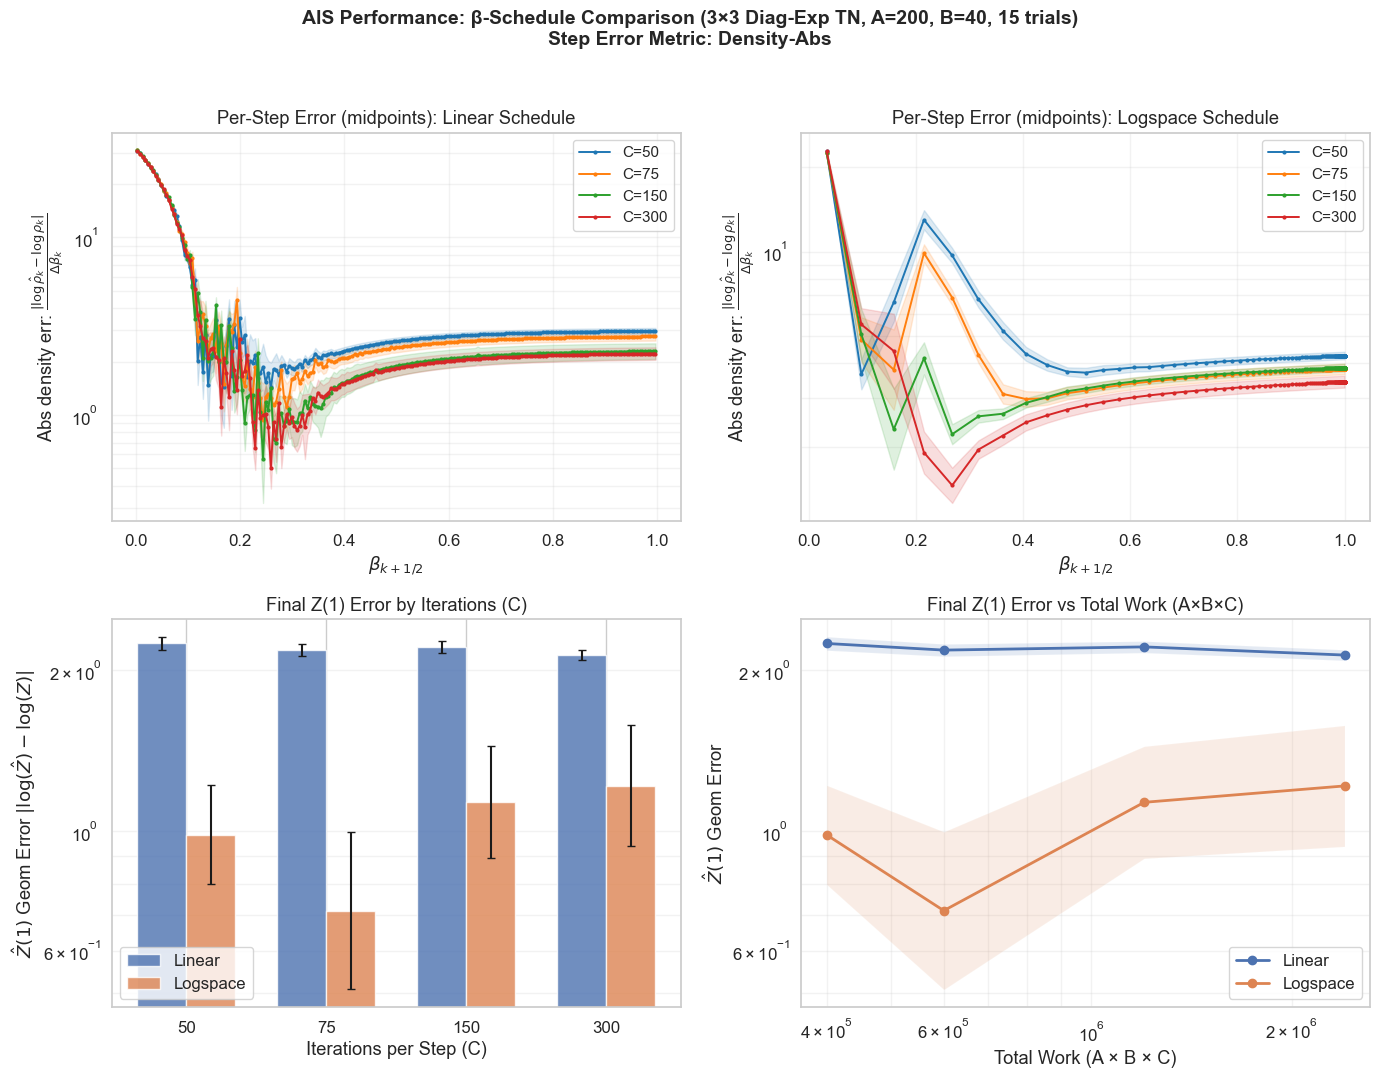

[done] saved plot -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/plots/ais_schedule_comparison.png
[done] saved traces -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/data/ais_schedule_comparison.csv


In [4]:
# C-sweep: per-step ratio geometric error across beta, comparing two beta schedules
# also plots final Z(1) estimate error to show accumulated error

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

A, B = 200, 40
C_list = [50, 75, 150, 300]
n_trials = 15
EPS = 1e-30
seed = 42

# step error metric: schedule-invariant log-ratio density error per unit β
#   density_abs:  |û_k - u_k| where u_k := log ρ_k / Δβ_k
#               equivalently: |log ρ̂_k - log ρ_k| / Δβ_k
#   density_rel:  |û_k - u_k| / (|u_k| + ε)
STEP_ERROR_METRIC = "density_abs"

# two beta schedules to compare
def make_linear_betas(A):
    return np.linspace(0.0, 1.0, A)

def make_logspace_betas(A):
    """
    Generate logspace beta schedule with much finer spacing near β=1.
    Note: The last Δβ is ~1e-6, so density_abs at the very end can spike
    (because we divide by a tiny number). This is not a code bug — it's why
    the integrated summaries E_L1, E_L2 are the better schedule-invariant scalars.
    """
    betas = 1.0 - np.logspace(0, np.log10(1e-6), A)
    betas[0] = 0.0
    betas[-1] = 1.0
    return np.sort(betas)

schedule_configs = {
    "Linear": make_linear_betas(A),
    "Logspace": make_logspace_betas(A),
}

sns.set_theme(style="whitegrid", font_scale=1.1)

def _to_numpy(x):
    """Convert cupy/np scalars/arrays to numpy arrays."""
    if hasattr(x, "get"):      # cupy ndarray
        return x.get()
    if hasattr(x, "to_numpy"): # some other backends
        return x.to_numpy()
    return np.asarray(x)

import zlib

def stable_hash_int(s: str) -> int:
    """Stable hash function for reproducibility (replaces Python's non-deterministic hash())."""
    return zlib.crc32(s.encode("utf-8"))  # 0..2**32-1

def _seed_everything(s):
    """Seed random number generators, capping seed to 32-bit range for consistency."""
    s = int(s) % (2**32 - 1)
    np.random.seed(s)
    try:
        import cupy as cp
        cp.random.seed(s)
    except Exception:
        pass

def geom_mean_and_band(err_mat, eps=EPS, z=1.0):
    """
    err_mat: (n_trials, K) or (n_trials,) > 0
    Return (gmean, lower, upper) using log-domain ± z*SE bands.
    """
    loge = np.log(np.clip(err_mat, eps, None))
    mu = loge.mean(axis=0)
    sd = loge.std(axis=0, ddof=1)
    se = sd / np.sqrt(err_mat.shape[0])
    g = np.exp(mu)
    lo = np.exp(mu - z * se)
    hi = np.exp(mu + z * se)
    return g, lo, hi

def geom_mean_scalar(arr, eps=EPS):
    """Geometric mean of 1D array."""
    return float(np.exp(np.mean(np.log(np.clip(arr, eps, None)))))

tn, _ = create_test_tensor_network(
    network_type="3x3_grid_diagexp", dim=3, seed=123, alpha=0.6
)
print("[info] created tensor network for C-sweep ratio-error experiment")

results_by_schedule = {}  # schedule_name {C -> {"step_errs": (n_trials, K), "Z1_errs": (n_trials,)}}

for sched_name, betas in schedule_configs.items():
    print(f"\n{'#' * 80}")
    print(f"# SCHEDULE: {sched_name}")
    print(f"{'#' * 80}")
    
    K = len(betas) - 1
    beta_left = betas[:-1]
    beta_right = betas[1:]
    delta_beta = np.diff(betas)
    # plot steps at midpoints (each increment lives on [β_k, β_{k+1}])
    beta_mid = 0.5 * (beta_left + beta_right)
    beta_x = beta_mid  # keep name for backward compatibility in the rest of the cell
    
    # exact Z(beta) for this schedule
    print(f"[info] computing exact Z(beta) for {sched_name} schedule...")
    Z_true_seq = exact_Z_over_betas(tn, betas)
    Z_true_final = float(Z_true_seq[-1])
    print(f"[info] exact Z at beta=1.0: Z_true = {Z_true_final:.6e}")
    
    true_ratios = Z_true_seq[1:] / Z_true_seq[:-1]
    
    # cheap assert: validate true_ratios
    if not np.all(np.isfinite(true_ratios)) or np.any(true_ratios <= 0):
        raise ValueError("true_ratios must be positive finite for log metric")
    
    errors_per_C = {}
    Z1_errors_per_C = {}
    EL1_errors_per_C = {}
    EL2_errors_per_C = {}
    
    mid_idx = int(np.argmin(np.abs(beta_mid - 0.5)))
    
    for C in C_list:
        all_step_errs = []
        all_Z1_errs = []
        all_EL1 = []
        all_EL2 = []
        start_C = time.time()
        
        print(f"\n{'=' * 72}")
        print(f"[info] {sched_name} | C = {C} mixing steps per beta step")
        print("=" * 72)
        
        for trial in range(n_trials):
            t0 = time.time()
            _seed_everything(seed + 100000 * C + trial + stable_hash_int(sched_name) % 10000)
            
            # one AIS run produces weights for *all* steps
            Z_ests, logZ_trajs, weights_by_beta = estimate_contraction(
                tn, betas, iters=C, burns=max(0, min(C // 10, C - 1)), n_chains=B, verbose=False
            )
            
            w = _to_numpy(weights_by_beta)
            w = np.asarray(w, dtype=np.float64)
            
            # robust shape validation: enforce (K, B)
            if w.ndim != 2:
                raise ValueError(f"weights_by_beta should be 2D, got shape {w.shape}")
            
            K_expected = len(betas) - 1
            if w.shape[0] == K_expected:
                pass  # already (K, B)
            elif w.shape[1] == K_expected:
                w = w.T  # transpose from (B, K) to (K, B)
            else:
                raise ValueError(f"weights_by_beta shape {w.shape} incompatible with K={K_expected}")
            
            rho_hat = w.mean(axis=1)  # (K,)
            
            # cheap assert: validate rho_hat
            if not np.all(np.isfinite(rho_hat)):
                raise ValueError("rho_hat has non-finite values")
            if np.any(rho_hat <= 0):
                print("[warn] rho_hat has nonpositive entries; clipping will occur")
            
            # compute step error: schedule-invariant per-unit-β log-increment density
            #   u_k := log ρ_k / Δβ_k,   û_k := log ρ̂_k / Δβ_k
            log_rho_hat = np.log(np.clip(rho_hat, EPS, None))
            log_rho_true = np.log(np.clip(true_ratios, EPS, None))
            db = np.clip(delta_beta, 1e-15, None)
            u_hat = log_rho_hat / db
            u_true = log_rho_true / db
            step_err = np.abs(u_hat - u_true)
            if STEP_ERROR_METRIC == "density_rel":
                step_err = step_err / (np.abs(u_true) + 1e-12)
            all_step_errs.append(step_err)

            # schedule-invariant integrated scalars per trial
            # E_L1 ≈ ∑ Δβ_k e_k ; E_L2 ≈ (∑ Δβ_k e_k^2)^{1/2}
            EL1 = float(np.sum(delta_beta * step_err))
            EL2 = float(np.sqrt(np.sum(delta_beta * (step_err ** 2))))
            all_EL1.append(EL1)
            all_EL2.append(EL2)
            
            # final Z(1) estimate error
            Z_ests_np = _to_numpy(Z_ests)       # shape (B,)
            Z1_est = float(np.mean(Z_ests_np))  # average across chains
            Z1_log_err = abs(np.log(max(Z1_est, EPS)) - np.log(max(Z_true_final, EPS)))
            all_Z1_errs.append(Z1_log_err)
            
            dt = time.time() - t0
            print(
                f"[trial {trial+1:02d}/{n_trials}] "
                f"time={dt:5.1f}s | "
                f"step err @ β≈0.5 -> {step_err[mid_idx]:.2e} | "
                f"E_L2 -> {EL2:.2e} | "
                f"Z(1) log err -> {Z1_log_err:.2e}"
            )
        
        errors_per_C[C] = np.vstack(all_step_errs)  # (n_trials, K)
        Z1_errors_per_C[C] = np.array(all_Z1_errs)  # (n_trials,)
        EL1_errors_per_C[C] = np.array(all_EL1)     # (n_trials,)
        EL2_errors_per_C[C] = np.array(all_EL2)     # (n_trials,)
        
        gm_step_last = geom_mean_scalar(errors_per_C[C][:, -1])
        gm_EL2 = geom_mean_scalar(EL2_errors_per_C[C])
        # Z1_log_err is already in log space, so arithmetic mean is the natural aggregation
        mean_Z1 = float(np.mean(Z1_errors_per_C[C]))
        C_dt = time.time() - start_C
        print(
            f"[summary] C={C:4d} | step geom err (last): {gm_step_last:.2e} | "
            f"E_L2 geom: {gm_EL2:.2e} | Z(1) mean err: {mean_Z1:.2e} | time={C_dt/60:.1f}min"
        )
    
    results_by_schedule[sched_name] = {
        "betas": betas,
        "beta_x": beta_x,  # midpoints
        "beta_left": beta_left,
        "beta_right": beta_right,
        "delta_beta": delta_beta,
        "true_ratios": true_ratios,
        "Z_true_final": Z_true_final,
        "step_errs": errors_per_C,
        "EL1_errs": EL1_errors_per_C,
        "EL2_errs": EL2_errors_per_C,
        "Z1_errs": Z1_errors_per_C,
    }

print("\n[info] all experiments complete")

# ---------- plot: 2x2 grid (step-ratio error for each schedule + Z(1) error) ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

if STEP_ERROR_METRIC == "density_abs":
    metric_label = r"Abs density err: $\frac{|\log\hat{\rho}_k-\log\rho_k|}{\Delta\beta_k}$"
    metric_name = "Density-Abs"
else:  # density_rel
    metric_label = r"Rel density err: $\frac{|\hat{u}_k-u_k|}{|u_k|+\epsilon}$, $u_k=\frac{\log\rho_k}{\Delta\beta_k}$"
    metric_name = "Density-Rel"

fig.suptitle(
    f"AIS Performance: β-Schedule Comparison (3×3 Diag-Exp TN, A={A}, B={B}, {n_trials} trials)\n"
    f"Step Error Metric: {metric_name}",
    fontsize=14, fontweight="bold", y=0.98
)
colors = sns.color_palette("tab10", n_colors=len(C_list))

# Row 1: Step-ratio geometric error for each schedule
for col, (sched_name, res) in enumerate(results_by_schedule.items()):
    ax = axes[0, col]
    beta_x = res["beta_x"]
    
    for i, C in enumerate(C_list):
        err_mat = res["step_errs"][C]
        g, lo, hi = geom_mean_and_band(err_mat, z=1.0)
        
        ax.semilogy(
            beta_x, g, marker="o", ms=2, lw=1.4, color=colors[i],
            label=f"C={C}"
        )
        ax.fill_between(beta_x, lo, hi, color=colors[i], alpha=0.15)
    
    ax.grid(True, which="both", alpha=0.25)
    ax.set_xlabel(r"$\beta_{k+1/2}$")
    ax.set_ylabel(metric_label)
    ax.set_title(f"Per-Step Error (midpoints): {sched_name} Schedule")
    ax.legend(loc="best", fontsize="small")

# Row 2: Final Z(1) geometric error comparison
ax_z1 = axes[1, 0]
bar_width = 0.35
x_pos = np.arange(len(C_list))

for idx, (sched_name, res) in enumerate(results_by_schedule.items()):
    means = []
    los = []
    his = []
    for C in C_list:
        Z1_errs = res["Z1_errs"][C]
        g, lo, hi = geom_mean_and_band(Z1_errs.reshape(-1, 1), z=1.0)
        means.append(g[0])
        los.append(g[0] - lo[0])
        his.append(hi[0] - g[0])
    
    offset = (idx - 0.5) * bar_width
    bars = ax_z1.bar(x_pos + offset, means, bar_width, 
                     yerr=[los, his], capsize=3,
                     label=sched_name, alpha=0.8)

ax_z1.set_yscale("log")
ax_z1.set_xticks(x_pos)
ax_z1.set_xticklabels([str(c) for c in C_list])
ax_z1.set_xlabel("Iterations per Step (C)")
ax_z1.set_ylabel(r"$\hat{Z}(1)$ Geom Error $|\log(\hat{Z}) - \log(Z)|$")
ax_z1.set_title("Final Z(1) Error by Iterations (C)")
ax_z1.legend(loc="best")
ax_z1.grid(True, which="both", alpha=0.25, axis="y")

# Row 2, Col 2: Z(1) error vs total work
ax_work = axes[1, 1]
for idx, (sched_name, res) in enumerate(results_by_schedule.items()):
    works = []
    means = []
    los = []
    his = []
    for C in C_list:
        Z1_errs = res["Z1_errs"][C]
        g, lo, hi = geom_mean_and_band(Z1_errs.reshape(-1, 1), z=1.0)
        works.append(A * B * C)
        means.append(g[0])
        los.append(lo[0])
        his.append(hi[0])
    
    ax_work.semilogy(works, means, marker="o", ms=6, lw=2, label=sched_name)
    ax_work.fill_between(works, los, his, alpha=0.15)

ax_work.set_xscale("log")
ax_work.set_xlabel("Total Work (A × B × C)")
ax_work.set_ylabel(r"$\hat{Z}(1)$ Geom Error")
ax_work.set_title("Final Z(1) Error vs Total Work (A×B×C)")
ax_work.legend(loc="best")
ax_work.grid(True, which="both", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle
plt.show()

# ---------- save outputs ----------
# plots go to ../plots/, data goes to ../data/
import os
plots_dir = os.path.join(os.path.dirname(os.getcwd()), "plots")
data_dir = os.path.join(os.path.dirname(os.getcwd()), "data")
os.makedirs(plots_dir, exist_ok=True)
os.makedirs(data_dir, exist_ok=True)

png_path = os.path.join(plots_dir, "ais_schedule_comparison.png")
fig.savefig(png_path, dpi=300, bbox_inches="tight")
print(f"[done] saved plot -> {png_path}")

# ---------- save raw traces ----------
rows = []
for sched_name, res in results_by_schedule.items():
    beta_mid = res["beta_x"]
    beta_left = res["beta_left"]
    beta_right = res["beta_right"]
    delta_beta = res["delta_beta"]
    true_ratios = res["true_ratios"]
    K = len(beta_mid)
    
    for C in C_list:
        step_err_mat = res["step_errs"][C]
        Z1_err_arr = res["Z1_errs"][C]
        EL1_arr = res["EL1_errs"][C]
        EL2_arr = res["EL2_errs"][C]
        
        for t in range(n_trials):
            # per-step errors
            for k in range(K):
                rows.append({
                    "schedule": sched_name,
                    "A": A, "B": B, "C": C,
                    "trial": t,
                    "beta_idx": k,
                    "beta_mid": float(beta_mid[k]),
                    "beta_left": float(beta_left[k]),
                    "beta_right": float(beta_right[k]),
                    "delta_beta": float(delta_beta[k]),
                    "true_ratio": float(true_ratios[k]),
                    "step_error": float(step_err_mat[t, k]),
                    "step_error_metric": STEP_ERROR_METRIC,
                    "E_L1": float(EL1_arr[t]),
                    "E_L2": float(EL2_arr[t]),
                    "Z1_log_error": float(Z1_err_arr[t]),
                })

out_df = pd.DataFrame(rows)
csv_path = os.path.join(data_dir, "ais_schedule_comparison.csv")
out_df.to_csv(csv_path, index=False)
print(f"[done] saved traces -> {csv_path}")


[info] loaded data from /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/data/ais_schedule_comparison.csv
[info] A=200, B=40, C_list=[np.int64(50), np.int64(75), np.int64(150), np.int64(300)], n_trials=15
[info] step error metric: density_abs


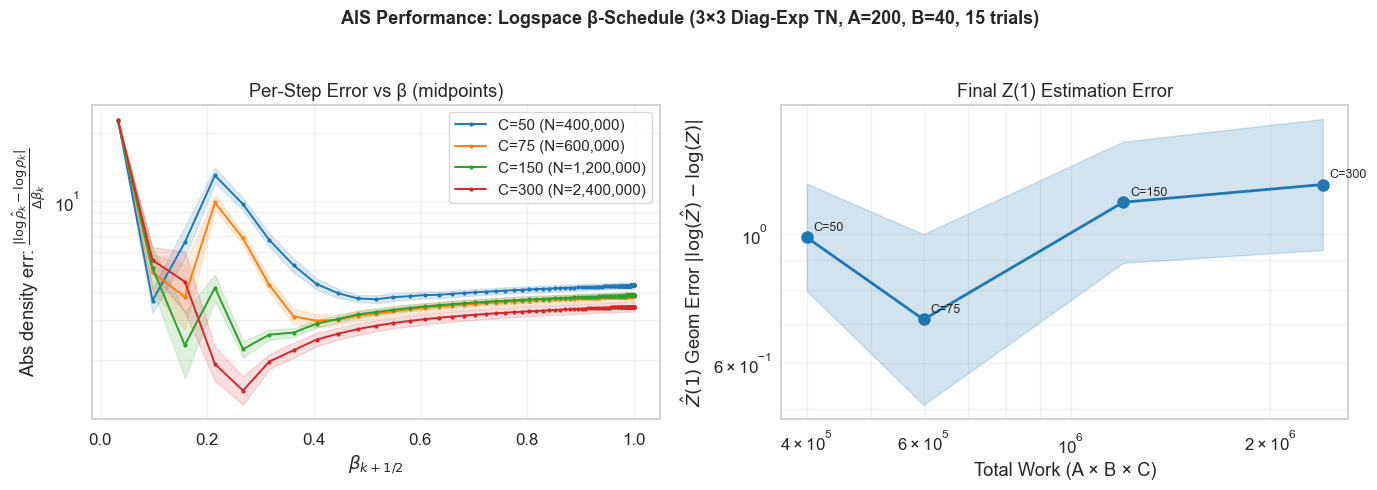

[done] saved plot -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/plots/ais_logspace_only.png


In [5]:
# plotting only the logspace schedule results

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_dir = os.path.join(os.path.dirname(os.getcwd()), "data")
csv_path = os.path.join(data_dir, "ais_schedule_comparison.csv")
df = pd.read_csv(csv_path)
print(f"[info] loaded data from {csv_path}")

df_log = df[df["schedule"] == "Logspace"].copy()

A = df_log["A"].iloc[0]
B = df_log["B"].iloc[0]
C_list = sorted(df_log["C"].unique())
n_trials = df_log["trial"].nunique()

print(f"[info] A={A}, B={B}, C_list={C_list}, n_trials={n_trials}")

# get the metric used from the data
step_metric = df_log["step_error_metric"].iloc[0] if "step_error_metric" in df_log.columns else "unknown"
print(f"[info] step error metric: {step_metric}")

if step_metric == "density_abs":
    metric_label = r"Abs density err: $\frac{|\log\hat{\rho}_k-\log\rho_k|}{\Delta\beta_k}$"
else:  # density_rel
    metric_label = r"Rel density err: $\frac{|\hat{u}_k-u_k|}{|u_k|+\epsilon}$"

EPS = 1e-30

def geom_mean_and_band(err_arr, eps=EPS, z=1.0):
    """Compute geometric mean and ±z*SE bands from 1D array of errors."""
    loge = np.log(np.clip(err_arr, eps, None))
    mu = loge.mean()
    sd = loge.std(ddof=1)
    se = sd / np.sqrt(len(err_arr))
    g = np.exp(mu)
    lo = np.exp(mu - z * se)
    hi = np.exp(mu + z * se)
    return g, lo, hi

sns.set_theme(style="whitegrid", font_scale=1.1)
colors = sns.color_palette("tab10", n_colors=len(C_list))

# step errors live on intervals [β_k, β_{k+1}] so we plot against midpoints when available
beta_col = "beta_mid" if "beta_mid" in df_log.columns else "beta"
beta_x = sorted(df_log[beta_col].unique())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"AIS Performance: Logspace β-Schedule (3×3 Diag-Exp TN, A={A}, B={B}, {n_trials} trials)",
    fontsize=13, fontweight="bold"
)

ax1 = axes[0]
for i, C in enumerate(C_list):
    df_c = df_log[df_log["C"] == C]
    
    # compute geom mean error at each beta
    gmeans, los, his = [], [], []
    for beta in beta_x:
        errs = df_c[df_c[beta_col] == beta]["step_error"].values
        g, lo, hi = geom_mean_and_band(errs)
        gmeans.append(g)
        los.append(lo)
        his.append(hi)
    
    # ax1.semilogy(beta_x, gmeans, marker="o", ms=2, lw=1.4, color=colors[i],
    #              label=f"C={C} (N={A*B*C:,})")
    # ax1.fill_between(beta_x, los, his, color=colors[i], alpha=0.15)
    ax1.plot(beta_x, gmeans, marker="o", ms=2, lw=1.4, color=colors[i],
             label=f"C={C} (N={A*B*C:,})")
    ax1.fill_between(beta_x, los, his, color=colors[i], alpha=0.15)

ax1.set_yscale("log")
ax1.grid(True, which="both", alpha=0.25)
ax1.set_xlabel(r"$\beta_{k+1/2}$")
ax1.set_ylabel(metric_label)
ax1.set_title("Per-Step Error vs β (midpoints)")
ax1.legend(loc="best", fontsize="small")

ax2 = axes[1]
works, means, lo_list, hi_list = [], [], [], []
for C in C_list:
    df_c = df_log[df_log["C"] == C]
    # Z1 error is same for all betas in a trial, so just get unique per trial
    Z1_errs = df_c.groupby("trial")["Z1_log_error"].first().values
    g, lo, hi = geom_mean_and_band(Z1_errs)
    works.append(A * B * C)
    means.append(g)
    lo_list.append(lo)
    hi_list.append(hi)

ax2.semilogy(works, means, marker="o", ms=8, lw=2, color="tab:blue", label="Logspace")
ax2.fill_between(works, lo_list, hi_list, alpha=0.2, color="tab:blue")

for w, m, c in zip(works, means, C_list):
    ax2.annotate(f"C={c}", (w, m), textcoords="offset points", xytext=(5, 5), fontsize=9)

ax2.set_xscale("log")
ax2.grid(True, which="both", alpha=0.25)
ax2.set_xlabel("Total Work (A × B × C)")
ax2.set_ylabel(r"$\hat{Z}(1)$ Geom Error $|\log(\hat{Z}) - \log(Z)|$")
ax2.set_title("Final Z(1) Estimation Error")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

plots_dir = os.path.join(os.path.dirname(os.getcwd()), "plots")
os.makedirs(plots_dir, exist_ok=True)
fig_path = os.path.join(plots_dir, "ais_logspace_only.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"[done] saved plot -> {fig_path}")


################################################################################
# TN TYPE: Uniform Around 1 (uniform1)
################################################################################

[uniform1] jitter = 0.05
  [info] computing exact Z(β) sequence...
  [info] exact Z(1) = 5.223708e+05 (took 0.1s)
    [trial 01/10] Z1_err=2.557e-03, time=9.8s
    [trial 02/10] Z1_err=2.702e-03, time=9.8s
    [trial 03/10] Z1_err=3.197e-03, time=9.7s
    [trial 04/10] Z1_err=1.400e-03, time=9.7s
    [trial 05/10] Z1_err=1.964e-03, time=9.6s
    [trial 06/10] Z1_err=2.355e-04, time=9.6s
    [trial 07/10] Z1_err=1.318e-03, time=9.6s
    [trial 08/10] Z1_err=2.158e-03, time=9.8s
    [trial 09/10] Z1_err=4.122e-03, time=9.7s
    [trial 10/10] Z1_err=4.674e-03, time=9.7s
  [summary] mean Z(1) error: 2.433e-03

[uniform1] jitter = 0.1
  [info] computing exact Z(β) sequence...
  [info] exact Z(1) = 5.132084e+05 (took 0.1s)
    [trial 01/10] Z1_err=2.759e-03, time=9.7s
    [trial 02/10] Z1_err

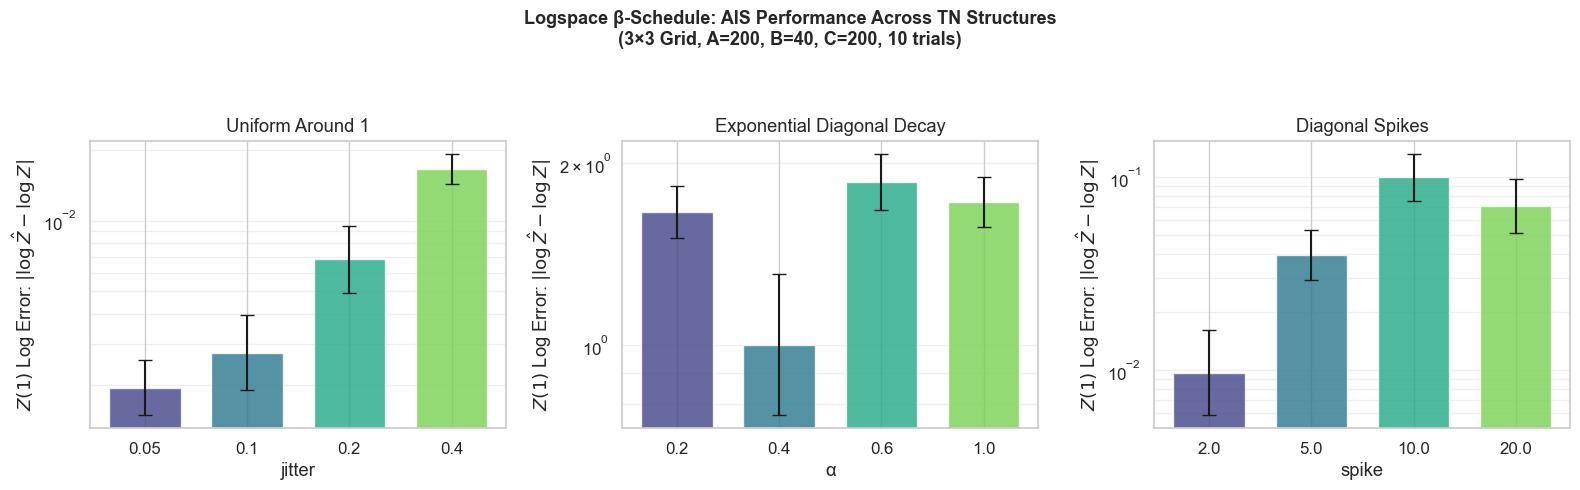

[done] saved plot -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/plots/ais_logspace_tn_comparison.png


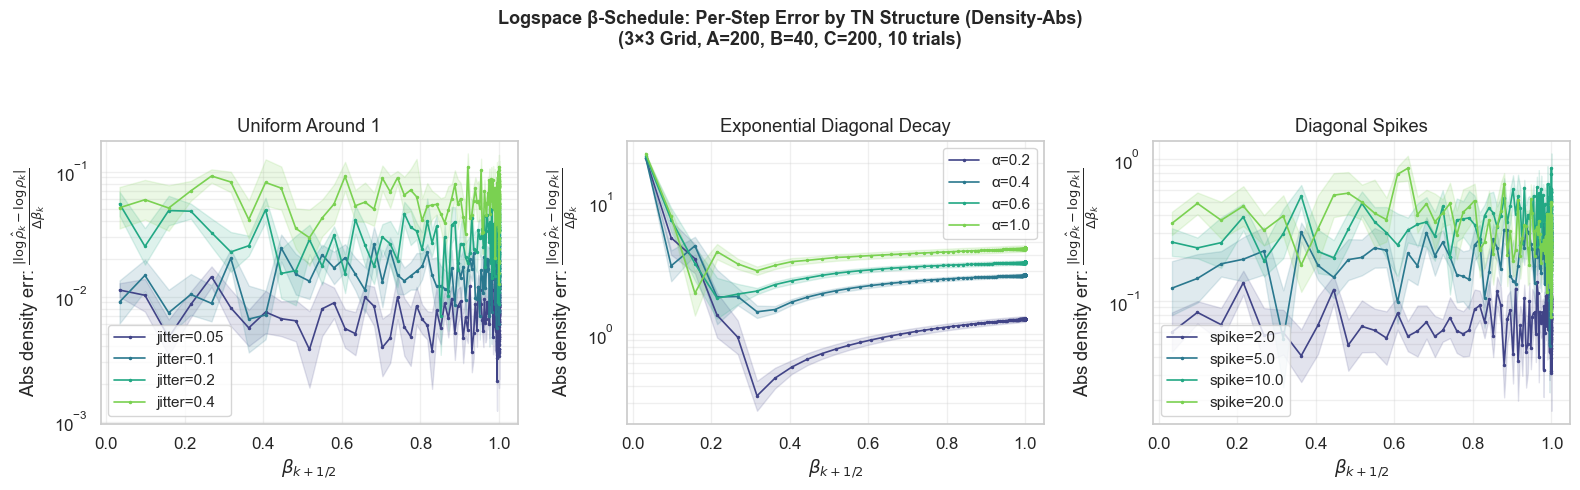

[done] saved plot -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/plots/ais_logspace_tn_step_errors.png
[done] saved data -> /Users/aniket/Documents/university/research/solomonik-group/mcmc-tensor-network/data/ais_logspace_tn_comparison.csv


In [6]:
# compare AIS performance (logspace beta schedule) across:
#   - uniform1: varying jitter (spread around 1)
#   - diagexp:  varying alpha (decay rate)
#   - spikes:   varying spike_factor (diagonal dominance)
# fixed: A=200 (beta steps), B=40 (chains), C=200 (iters per step)

import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# fixed parameters
A, B, C = 200, 40, 200
n_trials = 10
EPS = 1e-30
base_seed = 42
dim = 3

# step error metric: schedule-invariant log-ratio density error per unit β
#   density_abs: |log ρ̂_k - log ρ_k| / Δβ_k
#   density_rel: |û_k - u_k| / (|u_k| + ε), u_k := log ρ_k / Δβ_k
STEP_ERROR_METRIC = "density_abs"

def make_logspace_betas(A):
    """
    Generate logspace beta schedule with much finer spacing near β=1.
    Note: The last Δβ is ~1e-6, so density_abs at the very end can spike
    (because we divide by a tiny number). This is not a code bug — it's why
    the integrated summaries E_L1, E_L2 are the better schedule-invariant scalars.
    """
    betas = 1.0 - np.logspace(0, np.log10(1e-6), A)
    betas[0] = 0.0
    betas[-1] = 1.0
    return np.sort(betas)

betas = make_logspace_betas(A)
K = len(betas) - 1
beta_left = betas[:-1]
beta_right = betas[1:]
delta_beta = np.diff(betas)
beta_mid = 0.5 * (beta_left + beta_right)

# tn config
# each entry: (network_type, param_name, param_values, param_key)
tn_configs = {
    "uniform1": {
        "network_type": "3x3_grid_uniform1",
        "param_name": "jitter",
        "param_values": [0.05, 0.1, 0.2, 0.4],
        "param_key": "jitter",
        "title": "Uniform Around 1",
    },
    "diagexp": {
        "network_type": "3x3_grid_diagexp",
        "param_name": "α",
        "param_values": [0.2, 0.4, 0.6, 1.0],
        "param_key": "alpha",
        "title": "Exponential Diagonal Decay",
    },
    "spikes": {
        "network_type": "3x3_grid_spikes",
        "param_name": "spike",
        "param_values": [2.0, 5.0, 10.0, 20.0],
        "param_key": "spike_factor",
        "title": "Diagonal Spikes",
    },
}

# helpers
def _to_numpy(x):
    if hasattr(x, "get"):
        return x.get()
    if hasattr(x, "to_numpy"):
        return x.to_numpy()
    return np.asarray(x)

import zlib

def stable_hash_int(s: str) -> int:
    """Stable hash function for reproducibility (replaces Python's non-deterministic hash())."""
    return zlib.crc32(s.encode("utf-8"))  # 0..2**32-1

def _seed_everything(s):
    """Seed random number generators, capping seed to 32-bit range for consistency."""
    s = int(s) % (2**32 - 1)
    np.random.seed(s)
    try:
        import cupy as cp
        cp.random.seed(s)
    except Exception:
        pass

def geom_mean_and_band(err_arr, eps=EPS, z=1.0):
    """Geometric mean and ±z*SE bands for 1D array."""
    loge = np.log(np.clip(err_arr, eps, None))
    mu = loge.mean()
    sd = loge.std(ddof=1)
    se = sd / np.sqrt(len(err_arr))
    g = np.exp(mu)
    lo = np.exp(mu - z * se)
    hi = np.exp(mu + z * se)
    return g, lo, hi

# run experiments
results = {}  # tn_type -> {param_val -> {"Z1_errs": [...], "step_errs": [...]}}

for tn_type, cfg in tn_configs.items():
    print(f"\n{'#' * 80}")
    print(f"# TN TYPE: {cfg['title']} ({tn_type})")
    print(f"{'#' * 80}")
    
    results[tn_type] = {}
    
    for param_val in cfg["param_values"]:
        print(f"\n{'=' * 60}")
        print(f"[{tn_type}] {cfg['param_name']} = {param_val}")
        print("=" * 60)
        
        # create TN with this parameter
        tn_kwargs = {cfg["param_key"]: param_val}
        tn, _ = create_test_tensor_network(
            network_type=cfg["network_type"],
            dim=dim,
            seed=base_seed,
            **tn_kwargs
        )
        
        # compute exact Z(beta) for this TN
        print(f"  [info] computing exact Z(β) sequence...")
        t0 = time.time()
        Z_true_seq = exact_Z_over_betas(tn, betas)
        Z_true_final = float(Z_true_seq[-1])
        true_ratios = Z_true_seq[1:] / Z_true_seq[:-1]
        
        # cheap assert: validate true_ratios
        if not np.all(np.isfinite(true_ratios)) or np.any(true_ratios <= 0):
            raise ValueError("true_ratios must be positive finite for log metric")
        
        print(f"  [info] exact Z(1) = {Z_true_final:.6e} (took {time.time()-t0:.1f}s)")
        
        all_Z1_errs = []
        all_step_errs = []
        
        for trial in range(n_trials):
            t0 = time.time()
            trial_seed = base_seed + 10000 * trial + stable_hash_int(tn_type) % 1000 + int(param_val * 100)
            _seed_everything(trial_seed)
            
            # run AIS
            Z_ests, logZ_trajs, weights_by_beta = estimate_contraction(
                tn, betas, iters=C, burns=max(0, min(C // 10, C - 1)),
                n_chains=B, verbose=False
            )
            
            # compute step error: schedule-invariant per-unit-β log-increment density
            w = _to_numpy(weights_by_beta)
            w = np.asarray(w, dtype=np.float64)
            
            # robust shape validation: enforce (K, B)
            if w.ndim != 2:
                raise ValueError(f"weights_by_beta should be 2D, got shape {w.shape}")
            
            K_expected = len(betas) - 1
            if w.shape[0] == K_expected:
                pass  # already (K, B)
            elif w.shape[1] == K_expected:
                w = w.T  # transpose from (B, K) to (K, B)
            else:
                raise ValueError(f"weights_by_beta shape {w.shape} incompatible with K={K_expected}")
            
            rho_hat = w.mean(axis=1)  # (K,)
            
            # cheap assert: validate rho_hat
            if not np.all(np.isfinite(rho_hat)):
                raise ValueError("rho_hat has non-finite values")
            if np.any(rho_hat <= 0):
                print("[warn] rho_hat has nonpositive entries; clipping will occur")
            log_rho_hat = np.log(np.clip(rho_hat, EPS, None))
            log_rho_true = np.log(np.clip(true_ratios, EPS, None))
            db = np.clip(delta_beta, 1e-15, None)
            u_hat = log_rho_hat / db
            u_true = log_rho_true / db
            step_err = np.abs(u_hat - u_true)
            if STEP_ERROR_METRIC == "density_rel":
                step_err = step_err / (np.abs(u_true) + 1e-12)
            all_step_errs.append(step_err)
            
            # schedule-invariant integrated scalars per trial (optional)
            # E_L1 ≈ ∑ Δβ_k e_k ; E_L2 ≈ (∑ Δβ_k e_k^2)^{1/2}
            EL1 = float(np.sum(delta_beta * step_err))
            EL2 = float(np.sqrt(np.sum(delta_beta * (step_err ** 2))))
            
            # Z(1) error
            Z_ests_np = _to_numpy(Z_ests)
            Z1_est = float(np.mean(Z_ests_np))
            Z1_log_err = abs(np.log(max(Z1_est, EPS)) - np.log(max(Z_true_final, EPS)))
            all_Z1_errs.append(Z1_log_err)
            
            dt = time.time() - t0
            print(f"    [trial {trial+1:02d}/{n_trials}] Z1_err={Z1_log_err:.3e}, time={dt:.1f}s")
        
        results[tn_type][param_val] = {
            "Z1_errs": np.array(all_Z1_errs),
            "step_errs": np.vstack(all_step_errs),  # (n_trials, K)
            # optional schedule-invariant integrated scalars (recomputed from step_errs when needed)
            "Z_true_final": Z_true_final,
        }
        
        # Z1_log_err is already in log space, so arithmetic mean is the natural aggregation
        mean_Z1 = float(np.mean(all_Z1_errs))
        print(f"  [summary] mean Z(1) error: {mean_Z1:.3e}")

print("\n[info] all experiments complete!")

# plotting
sns.set_theme(style="whitegrid", font_scale=1.1)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"Logspace β-Schedule: AIS Performance Across TN Structures\n"
    f"(3×3 Grid, A={A}, B={B}, C={C}, {n_trials} trials)",
    fontsize=13, fontweight="bold"
)

for ax_idx, (tn_type, cfg) in enumerate(tn_configs.items()):
    ax = axes[ax_idx]
    param_vals = cfg["param_values"]
    colors = sns.color_palette("viridis", n_colors=len(param_vals))
    
    for i, param_val in enumerate(param_vals):
        Z1_errs = results[tn_type][param_val]["Z1_errs"]
        g, lo, hi = geom_mean_and_band(Z1_errs)
        
        # bar plot with error bars
        ax.bar(
            i, g, width=0.7, color=colors[i], alpha=0.8,
            yerr=[[g - lo], [hi - g]], capsize=5,
            label=f"{cfg['param_name']}={param_val}"
        )
    
    ax.set_yscale("log")
    ax.set_xticks(range(len(param_vals)))
    ax.set_xticklabels([str(v) for v in param_vals])
    ax.set_xlabel(cfg["param_name"])
    ax.set_ylabel(r"$Z(1)$ Log Error: $|\log\hat{Z} - \log Z|$")
    ax.set_title(cfg["title"])
    ax.grid(True, which="both", alpha=0.3, axis="y")

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# save the figure
plots_dir = os.path.join(os.path.dirname(os.getcwd()), "plots")
os.makedirs(plots_dir, exist_ok=True)
fig_path = os.path.join(plots_dir, "ais_logspace_tn_comparison.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"[done] saved plot -> {fig_path}")

# additional plot: step-ratio error curves
if STEP_ERROR_METRIC == "density_abs":
    metric_label = r"Abs density err: $\frac{|\log\hat{\rho}_k-\log\rho_k|}{\Delta\beta_k}$"
    metric_name = "Density-Abs"
else:  # density_rel
    metric_label = r"Rel density err: $\frac{|\hat{u}_k-u_k|}{|u_k|+\epsilon}$"
    metric_name = "Density-Rel"

fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
fig2.suptitle(
    f"Logspace β-Schedule: Per-Step Error by TN Structure ({metric_name})\n"
    f"(3×3 Grid, A={A}, B={B}, C={C}, {n_trials} trials)",
    fontsize=13, fontweight="bold"
)

beta_x = beta_mid

for ax_idx, (tn_type, cfg) in enumerate(tn_configs.items()):
    ax = axes2[ax_idx]
    param_vals = cfg["param_values"]
    colors = sns.color_palette("viridis", n_colors=len(param_vals))
    
    for i, param_val in enumerate(param_vals):
        step_errs = results[tn_type][param_val]["step_errs"]  # (n_trials, K)
        
        # geometric mean and bands across trials at each beta
        gmeans, los, his = [], [], []
        for k in range(K):
            g, lo, hi = geom_mean_and_band(step_errs[:, k])
            gmeans.append(g)
            los.append(lo)
            his.append(hi)
        
        ax.semilogy(
            beta_x, gmeans, marker="o", ms=1.5, lw=1.2, color=colors[i],
            label=f"{cfg['param_name']}={param_val}"
        )
        ax.fill_between(beta_x, los, his, color=colors[i], alpha=0.15)
    
    ax.set_xlabel(r"$\beta_{k+1/2}$")
    ax.set_ylabel(metric_label)
    ax.set_title(cfg["title"])
    ax.legend(loc="best", fontsize="small")
    ax.grid(True, which="both", alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

fig2_path = os.path.join(plots_dir, "ais_logspace_tn_step_errors.png")
fig2.savefig(fig2_path, dpi=300, bbox_inches="tight")
print(f"[done] saved plot -> {fig2_path}")

# save data
data_dir = os.path.join(os.path.dirname(os.getcwd()), "data")
os.makedirs(data_dir, exist_ok=True)

rows = []
for tn_type, cfg in tn_configs.items():
    for param_val in cfg["param_values"]:
        res = results[tn_type][param_val]
        for t in range(n_trials):
            for k in range(K):
                step_err = float(res["step_errs"][t, k])
                # integrated scalars (constant across k for a given trial)
                EL1 = float(np.sum(delta_beta * res["step_errs"][t, :]))
                EL2 = float(np.sqrt(np.sum(delta_beta * (res["step_errs"][t, :] ** 2))))
                rows.append({
                    "tn_type": tn_type,
                    "param_name": cfg["param_name"],
                    "param_value": param_val,
                    "A": A, "B": B, "C": C,
                    "trial": t,
                    "beta_idx": k,
                    "beta_mid": float(beta_mid[k]),
                    "beta_left": float(beta_left[k]),
                    "beta_right": float(beta_right[k]),
                    "delta_beta": float(delta_beta[k]),
                    "step_error": step_err,
                    "step_error_metric": STEP_ERROR_METRIC,
                    "E_L1": EL1,
                    "E_L2": EL2,
                    "Z1_log_error": float(res["Z1_errs"][t]),
                    "Z_true_final": res["Z_true_final"],
                })

df_out = pd.DataFrame(rows)
csv_path = os.path.join(data_dir, "ais_logspace_tn_comparison.csv")
df_out.to_csv(csv_path, index=False)
print(f"[done] saved data -> {csv_path}")
